# 1. Xử lí dữ liệu dạng text

In [1]:
import pandas as pd
import re
import unicodedata
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data.csv")
df.head()

,product_id,product_name,product_url,category_id,category_name,category_root_name,price,original_price,discount_rate,quantity_sold,...,origin,store_id,store_name,store_review_count,total_follower,is_official,cancel_by_seller_rate,cancel_by_seller_rate_status,return_rate,return_rate_status
0,276641167,Xe máy Honda Vision 2025 Cao Cấp,https://tiki.vn/xe-may-honda-vision-2025-cao-c...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,34500000.0,34600000.0,0.0,21.0,...,Nhật Bản / Việt Nam,18792.0,HEAD Phát Tiến,4767.0,5517.0,0.0,0.0,normal,0.0,normal
1,276626995,Xe Máy Honda Vision 2025 - Phiên Bản Thể Thao,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,38659000.0,38759000.0,0.0,32.0,...,Việt Nam,180553.0,Honda ủy nhiệm Hoàng Việt,919.0,2265.0,0.0,0.0,normal,0.0,normal
2,276626834,Xe Máy Honda Vision 2025 - Phiên Bản Đặc Biệt,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,36608000.0,36708000.0,0.0,25.0,...,Việt Nam,180553.0,Honda ủy nhiệm Hoàng Việt,919.0,2265.0,0.0,0.0,normal,0.0,normal
3,276626812,Xe máy Honda Vision 2025 Đặc Biệt,https://tiki.vn/xe-may-honda-vision-2025-dac-b...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,36920000.0,37020000.0,0.0,15.0,...,Nhật Bản / Việt Nam,18792.0,HEAD Phát Tiến,4767.0,5517.0,0.0,0.0,normal,0.0,normal
4,276626642,Xe Máy Honda Vision 2025 - Phiên Bản Cao Cấp,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,34762000.0,34862000.0,0.0,16.0,...,Việt Nam,180553.0,Honda ủy nhiệm Hoàng Việt,919.0,2265.0,0.0,0.0,normal,0.0,normal


In [3]:
# Lấy kiểu dữ liệu
df.dtypes

product_id                        int64
product_name                     object
product_url                      object
category_id                       int64
category_name                    object
category_root_name               object
price                           float64
original_price                  float64
discount_rate                   float64
quantity_sold                   float64
rating_average                  float64
review_count                    float64
is_return_policy                float64
is_freeship_xtra                float64
is_authentic                    float64
image_count                     float64
video_count                     float64
is_brand                        float64
brand_name                       object
origin                           object
store_id                        float64
store_name                       object
store_review_count              float64
total_follower                  float64
is_official                     float64


In [4]:
# Các cột text
text_cols = [
    'product_id',
    'product_name',
    'product_url',
    'category_id',
    'category_name',
    'category_root_name',
    'brand_name',
    'origin',
    'store_id',
    'store_name',
    'cancel_by_seller_rate_status',
    'return_rate_status'
    ]

1. Khám phá và xử lý Missing Value (MV) dạng text

In [5]:
# In những cột missing value và tỷ lệ missing value

# Dictionary để lưu cột và số dòng bị thiếu ở cột đó
missing_dict = {}

count = 0
for col in text_cols:
    number_missing_value = df[col].isnull().sum()
    if(number_missing_value>0): 
        count+=1
    missing_dict.update({col:number_missing_value})

print(f"{'Cột':30} {'Số lượng':10} {'Phần trăm':10}")
print("-" * 55)

for col, val in missing_dict.items():
    percent = round(val / len(df) * 100, 3)
    print(f"{col:30} {val:<10} {percent:<10}%")

print("\nSố cột chứa missing value: ", count)

Cột                            Số lượng   Phần trăm 
-------------------------------------------------------
product_id                     0          0.0       %
product_name                   0          0.0       %
product_url                    0          0.0       %
category_id                    0          0.0       %
category_name                  0          0.0       %
category_root_name             0          0.0       %
brand_name                     247        1.246     %
origin                         1002       5.056     %
store_id                       120        0.606     %
store_name                     208        1.05      %
cancel_by_seller_rate_status   120        0.606     %
return_rate_status             120        0.606     %

Số cột chứa missing value:  6


In [6]:
# Đối với brand_name và origin điền "Unknown"
print("Số lượng missing value trước khi điền: ")
for col in ['brand_name','origin']:
    print(f"{col}: {missing_dict[col]}")
    df[col] = df[col].fillna('Unknown')

# Kiểm tra và cập nhật missing_dict
print("Số lượng missing value sau khi điền: ")
for col in ['brand_name','origin']:
    number_missing_value = df[col].isna().sum()
    missing_dict[col] = number_missing_value
    
    print(f"{col}: {missing_dict[col]}")    

Số lượng missing value trước khi điền: 
brand_name: 247
origin: 1002
Số lượng missing value sau khi điền: 
brand_name: 0
origin: 0


In [7]:
# Đối với store_id, giá trị thiếu điền 0
print("Số lượng missing value trước khi điền: ")
for col in ['store_id']:
    print(f"{col}: {missing_dict[col]}")
    df[col] = df[col].fillna(0)

# Kiểm tra và cập nhật missing_dict
print("Số lượng missing value sau khi điền: ")
for col in ['store_id']:
    number_missing_value = df[col].isna().sum()
    missing_dict[col] = number_missing_value
    
    print(f"{col}: {missing_dict[col]}")    

Số lượng missing value trước khi điền: 
store_id: 120
Số lượng missing value sau khi điền: 
store_id: 0


In [8]:
# Đối với store_name, lấy store_id và đối chiếu với các hàng khác để tìm store_name
# Nếu không có thì điền "Unknown"

print("Số lượng missing value trước khi điền: ")
for col in ['store_name']:
    print(f"{col}: {missing_dict[col]}")
    
# Tạo dictionary mapping store_id -> store_name
store_map = df.dropna(subset=['store_name']).drop_duplicates('store_id')
store_map = store_map.set_index('store_id')['store_name'].to_dict()

def fill_store_name(row):
    if pd.isna(row['store_name']):
        return store_map.get(row['store_id'], "Unknown")
    return row['store_name']

df['store_name'] = df.apply(fill_store_name, axis =1)

# Thống kê số lượng "Unknown"
unknown_count = (df['store_name'] == "Unknown").sum()
unknown_percent = round(unknown_count / missing_dict['store_name'] * 100, 3)
print(f"\nTỷ lệ Unknown trong {missing_dict['store_name']} giá trị missing value:", unknown_percent, "%")

# Kiểm tra và cập nhật missing_dict
print("\nSố lượng missing value sau khi điền: ")
for col in ['store_name']:
    number_missing_value = df[col].isna().sum()
    missing_dict[col] = number_missing_value
    
    print(f"{col}: {missing_dict[col]}")      

Số lượng missing value trước khi điền: 
store_name: 208

Tỷ lệ Unknown trong 208 giá trị missing value: 69.712 %

Số lượng missing value sau khi điền: 
store_name: 0


In [9]:
# Đối với cancel_by_seller_rate_status nếu cancel_by_seller_rate tồn tại thì điền mode
# Nếu không tồn tại thì điền Unknown
print("Số lượng missing value trước khi điền: ")
for col in ['cancel_by_seller_rate_status']:
    print(f"{col}: {missing_dict[col]}")

# Lấy giá trị mode
mode_status = df['cancel_by_seller_rate_status'].mode()
# Lấy giá trị mode đầu tiên
if len(mode_status) > 0:
    mode_status = mode_status.iloc[0]
else:
    mode_status = "Unknown"

# Điền giá trị
df['cancel_by_seller_rate_status'] = df.apply(
    lambda row: mode_status if pd.notnull(row['cancel_by_seller_rate']) and pd.isnull(row['cancel_by_seller_rate_status'])
                else ("Unknown" if pd.isnull(row['cancel_by_seller_rate']) and pd.isnull(row['cancel_by_seller_rate_status'])
                      else row['cancel_by_seller_rate_status']),
    axis=1
)
# Kiểm tra và cập nhật missing_dict
print("Số lượng missing value sau khi điền: ")
for col in ['cancel_by_seller_rate_status']:
    number_missing_value = df[col].isna().sum()
    missing_dict[col] = number_missing_value
    
    print(f"{col}: {missing_dict[col]}")  


Số lượng missing value trước khi điền: 
cancel_by_seller_rate_status: 120
Số lượng missing value sau khi điền: 
cancel_by_seller_rate_status: 0


In [10]:
# Đối với return_rate_status nếu return_rate tồn tại thì điền mode
# Nếu không tồn tại thì điền Unknown
 
print("Số lượng missing value trước khi điền: ")
for col in ['return_rate_status']:
    print(f"{col}: {missing_dict[col]}")

# Lấy giá trị mode
mode_status = df['return_rate_status'].mode()
# Lấy giá trị mode đầu tiên
if len(mode_status) > 0:
    mode_status = mode_status.iloc[0]
else:
    mode_status = "Unknown"

# Điền giá trị
df['return_rate_status'] = df.apply(
    lambda row: mode_status if pd.notnull(row['return_rate']) and pd.isnull(row['return_rate_status'])
                else ("Unknown" if pd.isnull(row['return_rate']) and pd.isnull(row['return_rate_status'])
                      else row['return_rate_status']),
    axis=1
)
# Kiểm tra và cập nhật missing_dict
print("Số lượng missing value sau khi điền: ")
for col in ['return_rate_status']:
    number_missing_value = df[col].isna().sum()
    missing_dict[col] = number_missing_value
    
    print(f"{col}: {missing_dict[col]}")  

Số lượng missing value trước khi điền: 
return_rate_status: 120
Số lượng missing value sau khi điền: 
return_rate_status: 0


In [11]:
# Thống kê lại sau khi điền
missing_dict = {}

count = 0
for col in text_cols:
    number_missing_value = df[col].isnull().sum()
    if(number_missing_value>0): 
        count+=1
    missing_dict.update({col:number_missing_value})

print(f"{'Cột':30} {'Số lượng':10} {'Phần trăm':10}")
print("-" * 55)

for col, val in missing_dict.items():
    percent = round(val / len(df) * 100, 3)
    print(f"{col:30} {val:<10} {percent:<10}%")

print("\nSố cột chứa missing value: ", count)

Cột                            Số lượng   Phần trăm 
-------------------------------------------------------
product_id                     0          0.0       %
product_name                   0          0.0       %
product_url                    0          0.0       %
category_id                    0          0.0       %
category_name                  0          0.0       %
category_root_name             0          0.0       %
brand_name                     0          0.0       %
origin                         0          0.0       %
store_id                       0          0.0       %
store_name                     0          0.0       %
cancel_by_seller_rate_status   0          0.0       %
return_rate_status             0          0.0       %

Số cột chứa missing value:  0


2. Chuẩn hóa text (origin)

In [12]:
def normalize_text(s):
    """
    Chuyển chuỗi về chữ thường, loại bỏ khoảng trắng thừa và kí tự đặc biệt
    """
    if not isinstance(s, str):
        return ""
    s = unicodedata.normalize("NFC", s)
    s = s.replace("...", " ")
    s = re.sub(r"\(.*?\)", "", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip().lower()

In [13]:
# Chuẩn hóa xuất xứ VN, VietNam, Việt Nam,...
def clean_origin(origin):
    if not isinstance(origin, str) or origin.strip() == "":
        return "Other"

    text = normalize_text(origin)

    # Tách theo nhiều dạng dấu phân cách
    parts = re.split(r"[/,;|]", text)
    parts = [p.strip() for p in parts if p.strip()]

    # Từ điển chuẩn hóa về tên quốc gia tiếng Anh
    mapping = {
        # Việt Nam
        "việt nam": "Vietnam", "viet nam": "Vietnam", "vietnam": "Vietnam",

        # Trung Quốc
        "trung quốc": "China", "trung quoc": "China", "china": "China",
        "tq": "China", "hn/tq": "China", "hk/tq": "China",

        # Nhật Bản
        "nhật bản": "Japan", "nhat ban": "Japan", "japan": "Japan",

        # Hàn Quốc
        "hàn quốc": "South Korea", "han quoc": "South Korea",
        "korea": "South Korea", "south korea": "South Korea",

        # Mỹ
        "mỹ": "USA", "my": "USA", "usa": "USA",
        "united states": "USA", "us": "USA",

        # Hong Kong
        "hong kong": "Hong Kong", "hồng kông": "Hong Kong", "hk": "Hong Kong",

        # Đài Loan
        "đài loan": "Taiwan", "dai loan": "Taiwan", "taiwan": "Taiwan",

        # Ấn Độ
        "ấn độ": "India", "an do": "India", "india": "India",

        # Thái Lan
        "thái lan": "Thailand", "thai lan": "Thailand", "thailand": "Thailand",

        # Đức
        "đức": "Germany", "duc": "Germany", "germany": "Germany",

        # Anh
        "anh": "UK", "england": "UK", "uk": "UK",

        # Pháp
        "pháp": "France", "phap": "France", "france": "France",

        # Úc
        "úc": "Australia", "uc": "Australia", "australia": "Australia",

        # Italy
        "ý": "Italy", "y": "Italy", "italia": "Italy", "italy": "Italy",

        # Malaysia
        "malaysia": "Malaysia", "mã lai": "Malaysia",

        # Philippines
        "philippines": "Philippines", "philipin": "Philippines",
        "philipines": "Philippines", "philipin": "Philippines",

        # Singapore
        "singapore": "Singapore",

        # Hà Lan
        "hà lan": "Netherlands", "ha lan": "Netherlands",

        # Thổ Nhĩ Kỳ
        "thổ nhĩ kì": "Turkey", "thổ nhĩ kỳ": "Turkey",
        "tho nhi ky": "Turkey", "turkey": "Turkey",

        # Pakistan
        "pakistan": "Pakistan",

        # Iran
        "iran": "Iran",

        # Myanmar
        "myanmar": "Myanmar",

        # Cambodia
        "campuchia": "Cambodia", "cam pu chia": "Cambodia", "cambodia": "Cambodia",

        # Ai Cập
        "ai cập": "Egypt", "ai cap": "Egypt", "egypt": "Egypt",

        # Nga
        "nga": "Russia", "russia": "Russia",

        # Canada
        "canada": "Canada",

        # Ba Lan
        "ba lan": "Poland", "poland": "Poland",

        # Hungary
        "hungary": "Hungary",

        # Cộng Hòa Séc
        "cộng hòa séc": "Czech Republic", "sec": "Czech Republic",
        "czech": "Czech Republic",

        # Bỉ
        "bỉ": "Belgium", "bi": "Belgium", "belgium": "Belgium",

        # Israel
        "israel": "Israel",

        # Chile
        "chile": "Chile",

        # Mexico
        "mexico": "Mexico",

        # Ireland
        "ireland": "Ireland",

        # Nam Phi
        "nam phi": "South Africa", "south africa": "South Africa",

        # Ukraine
        "ukraine": "Ukraine",

        # Tunisia
        "tunisia": "Tunisia",

        # Cuba
        "cuba": "Cuba",

        # Sri Lanka
        "sri lanka": "Sri Lanka",

        # Brazil
        "brazil": "Brazil",

        # Madagascar
        "madagascar": "Madagascar",

        # Đan Mạch
        "đan mạch": "Denmark", "dan mach": "Denmark",

        # Hy Lạp
        "hy lạp": "Greece", "hy lap": "Greece", "greece": "Greece",

        # Thụy Điển
        "thụy điển": "Sweden", "thuy dien": "Sweden", "sweden": "Sweden",

        # Thụy Sĩ
        "thụy sỹ": "Switzerland", "thuy sy": "Switzerland",
        "switzerland": "Switzerland",

        # United Kingdom, Scotland
        "scotland": "UK",

        # New Zealand
        "new zealand": "New Zealand",

        # Slovenia
        "slovenia": "Slovenia",

        # Áo
        "áo": "Austria", "ao": "Austria", "austria": "Austria",

        # Finland
        "phần lan": "Finland", "phan lan": "Finland", "finland": "Finland",

        # Nhiều giá trị đặc biệt
        "nhiều quốc gia": "Other",
        "khác": "Other",
        "unknown": "Other",
        "không xác định": "Other",
    }

    result = set()

    for p in parts:
        if p in mapping:
            result.add(mapping[p])
            continue
        # Không nhận diện được → Other
        result.add("Other")

    if len(result) == 0:
        return "Other"

    # Sắp xếp cho đẹp
    return ", ".join(sorted(result))

In [14]:
df['origin'] = df['origin'].apply(clean_origin)
print(df['origin'].unique())

['Japan, Vietnam' 'Vietnam' 'Other' 'Taiwan' 'Japan' 'China' 'Hong Kong'
 'China, Hong Kong' 'Taiwan, Vietnam' 'China, Vietnam' 'China, USA'
 'Other, Vietnam' 'South Korea' 'China, India' 'UK' 'USA' 'Germany'
 'Thailand' 'China, South Korea' 'China, Taiwan, Thailand' 'Australia'
 'India' 'Poland' 'Canada' 'France' 'Philippines' 'UK, Vietnam' 'Malaysia'
 'Italy' 'Singapore' 'Pakistan' 'Iran' 'Myanmar' 'New Zealand' 'Chile'
 'Mexico' 'Ireland' 'South Africa' 'Ukraine' 'China, Singapore, Vietnam'
 'China, India, Taiwan, Vietnam' 'China, Taiwan'
 'China, South Korea, Vietnam' 'China, Malaysia' 'Cambodia, Vietnam'
 'China, Thailand' 'China, Philippines, South Korea, Vietnam'
 'India, Vietnam' 'China, Japan' 'China, Malaysia, Thailand' 'Hungary'
 'Czech Republic' 'Netherlands' 'Austria, Germany, Hungary, Poland'
 'Switzerland' 'Cambodia' 'Tunisia' 'China, Japan, Taiwan'
 'China, Other, Thailand, Vietnam' 'China, India, South Korea, Vietnam'
 'China, Germany, Vietnam' 'Other, South Korea, Vie

In [15]:
# Lấy giá trị để one-hot encoding
def split_origin(s):
    """
    Tách tất cả các giá trị trong cột origin thành list
    """
    if not isinstance(s, str):
        return []
    # Tách theo dấu phẩy, '/', '-', giữ các giá trị quốc gia
    parts = re.split(r'[,/\-]', s)
    # Xóa khoảng trắng thừa
    parts = [p.strip() for p in parts if p.strip()]
    return parts

# Tạo cột mới dạng list
df['origin_list'] = df['origin'].apply(split_origin)

In [16]:
# One-hot encoding
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
origin_encoded = pd.DataFrame(mlb.fit_transform(df['origin_list']),
                              columns=mlb.classes_,
                              index=df.index)

# Lưu lại các cột
origin_cols = origin_encoded.columns.tolist()
# Nối vào DataFrame gốc
df = pd.concat([df, origin_encoded], axis=1)

# Xóa cột tạm
df.drop(columns=['origin_list'], inplace=True)

df.head()

,product_id,product_name,product_url,category_id,category_name,category_root_name,price,original_price,discount_rate,quantity_sold,...,Sweden,Switzerland,Taiwan,Thailand,Tunisia,Turkey,UK,USA,Ukraine,Vietnam
0,276641167,Xe máy Honda Vision 2025 Cao Cấp,https://tiki.vn/xe-may-honda-vision-2025-cao-c...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,34500000.0,34600000.0,0.0,21.0,...,0,0,0,0,0,0,0,0,0,1
1,276626995,Xe Máy Honda Vision 2025 - Phiên Bản Thể Thao,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,38659000.0,38759000.0,0.0,32.0,...,0,0,0,0,0,0,0,0,0,1
2,276626834,Xe Máy Honda Vision 2025 - Phiên Bản Đặc Biệt,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,36608000.0,36708000.0,0.0,25.0,...,0,0,0,0,0,0,0,0,0,1
3,276626812,Xe máy Honda Vision 2025 Đặc Biệt,https://tiki.vn/xe-may-honda-vision-2025-dac-b...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,36920000.0,37020000.0,0.0,15.0,...,0,0,0,0,0,0,0,0,0,1
4,276626642,Xe Máy Honda Vision 2025 - Phiên Bản Cao Cấp,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,34762000.0,34862000.0,0.0,16.0,...,0,0,0,0,0,0,0,0,0,1


In [17]:
# Tính tổng từng cột one-hot
origin_per = (df[origin_cols].sum() / len(df) * 100)

# Cột giữ lại (>2%)
keep_origin = origin_per[origin_per > 2].index.tolist()
# Cột gộp vào Others (≤2%)
other_origin = origin_per[origin_per <= 2].index.tolist()

# Tạo cột Others bằng tổng các cột nhỏ
df['Others'] = df[other_origin].sum(axis=1) + df['Other']

# Xóa các cột nhỏ
df.drop(columns=other_origin, inplace=True)

In [18]:
df.head()

,product_id,product_name,product_url,category_id,category_name,category_root_name,price,original_price,discount_rate,quantity_sold,...,return_rate,return_rate_status,China,Japan,Other,South Korea,Thailand,USA,Vietnam,Others
0,276641167,Xe máy Honda Vision 2025 Cao Cấp,https://tiki.vn/xe-may-honda-vision-2025-cao-c...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,34500000.0,34600000.0,0.0,21.0,...,0.0,normal,0,1,0,0,0,0,1,0
1,276626995,Xe Máy Honda Vision 2025 - Phiên Bản Thể Thao,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,38659000.0,38759000.0,0.0,32.0,...,0.0,normal,0,0,0,0,0,0,1,0
2,276626834,Xe Máy Honda Vision 2025 - Phiên Bản Đặc Biệt,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,36608000.0,36708000.0,0.0,25.0,...,0.0,normal,0,0,0,0,0,0,1,0
3,276626812,Xe máy Honda Vision 2025 Đặc Biệt,https://tiki.vn/xe-may-honda-vision-2025-dac-b...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,36920000.0,37020000.0,0.0,15.0,...,0.0,normal,0,1,0,0,0,0,1,0
4,276626642,Xe Máy Honda Vision 2025 - Phiên Bản Cao Cấp,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,34762000.0,34862000.0,0.0,16.0,...,0.0,normal,0,0,0,0,0,0,1,0


3. Xử lý các product_id và product_url

In [19]:
# Kiểm tra để đảm bảo không có giá trị trùng lặp hoặc không hợp lệ
product_cols = ['product_id', 'product_url']

for col in product_cols:
    duplicates = df[col][df[col].duplicated()]
    if not duplicates.empty:
        print(f"Có giá trị trùng trong cột '{col}':")
        print(duplicates.unique())
    else:
        print(f"Không có giá trị trùng trong cột '{col}':")

Không có giá trị trùng trong cột 'product_id':
Không có giá trị trùng trong cột 'product_url':


In [20]:
# Lưu file
df.to_csv("processed_data.csv",index=False)

# 2. Question: 

In [21]:
df = pd.read_csv("processed_data.csv")
df.head()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19484\3168303030.py:1: DtypeWarning: Columns (25,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("processed_data.csv")


,product_id,product_name,product_url,category_id,category_name,category_root_name,price,original_price,discount_rate,quantity_sold,...,return_rate,return_rate_status,China,Japan,Other,South Korea,Thailand,USA,Vietnam,Others
0,276641167,Xe máy Honda Vision 2025 Cao Cấp,https://tiki.vn/xe-may-honda-vision-2025-cao-c...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,34500000.0,34600000.0,0.0,21.0,...,0.0,normal,0,1,0,0,0,0,1,0
1,276626995,Xe Máy Honda Vision 2025 - Phiên Bản Thể Thao,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,38659000.0,38759000.0,0.0,32.0,...,0.0,normal,0,0,0,0,0,0,1,0
2,276626834,Xe Máy Honda Vision 2025 - Phiên Bản Đặc Biệt,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,36608000.0,36708000.0,0.0,25.0,...,0.0,normal,0,0,0,0,0,0,1,0
3,276626812,Xe máy Honda Vision 2025 Đặc Biệt,https://tiki.vn/xe-may-honda-vision-2025-dac-b...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,36920000.0,37020000.0,0.0,15.0,...,0.0,normal,0,1,0,0,0,0,1,0
4,276626642,Xe Máy Honda Vision 2025 - Phiên Bản Cao Cấp,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,34762000.0,34862000.0,0.0,16.0,...,0.0,normal,0,0,0,0,0,0,1,0


1. Xuất xứ (origin) của sản phẩm có tác động đáng kể tới hiệu quả bán hàng (quantity_sold) không? 

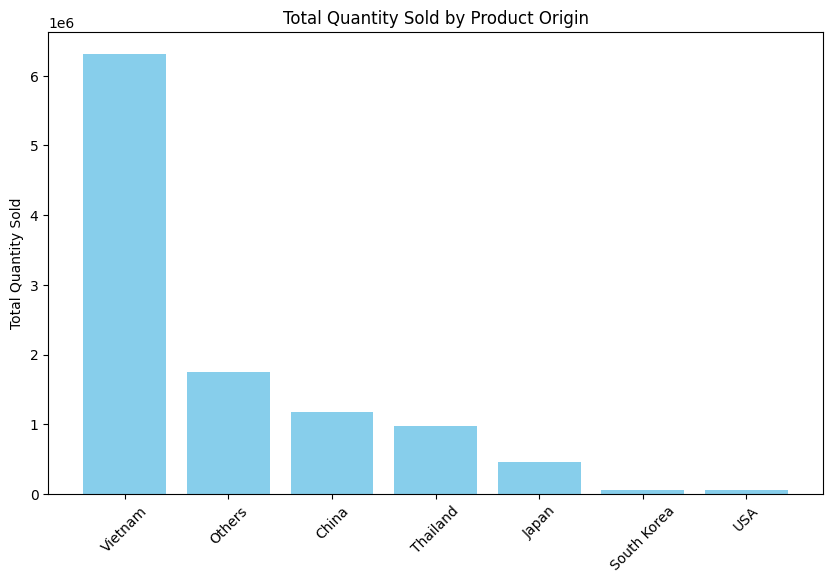

In [22]:
origin_cols = ['China','Japan','South Korea','Thailand','USA','Vietnam','Others']
origin_sales = {}
for col in origin_cols:
    origin_sales[col] = (df[col]*df['quantity_sold']).sum()

# Chuyển về DataFrame
origin_sales_df = pd.DataFrame({
    'Origin': origin_sales.keys(),
    'Total_sold': origin_sales.values()
}).sort_values(by ='Total_sold', ascending=False)

# Vẽ bar chart
plt.figure(figsize=(10,6))
plt.bar(origin_sales_df['Origin'], origin_sales_df['Total_sold'], color='skyblue')
plt.xticks(rotation=45)
plt.ylabel('Total Quantity Sold')
plt.title('Total Quantity Sold by Product Origin')
plt.show()

2. Xuất xứ nào chiếm ưu thế trên thị trường Tiki

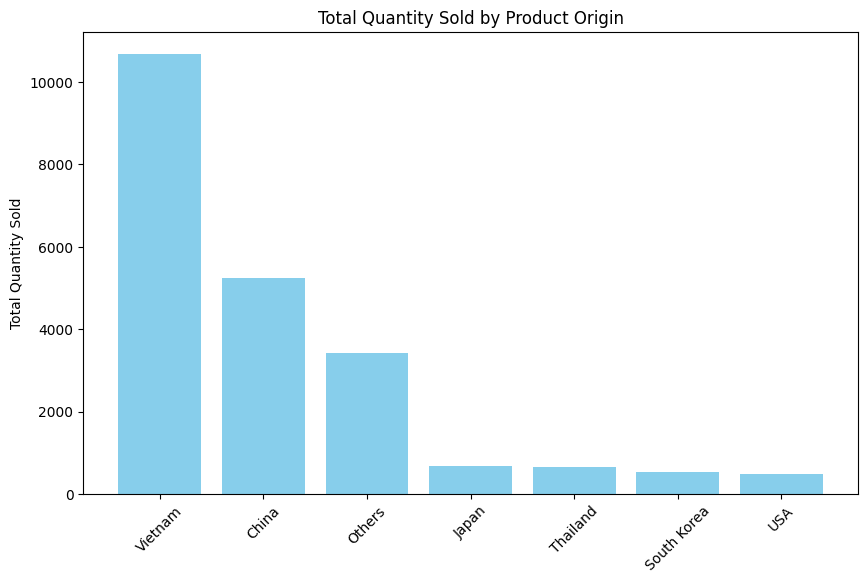

In [23]:
origin_cols = ['China','Japan','South Korea','Thailand','USA','Vietnam','Others']
origin_sales = {}
for col in origin_cols:
    origin_sales[col] = df[col].sum()

# Chuyển về DataFrame
origin_sales_df = pd.DataFrame({
    'Origin': origin_sales.keys(),
    'Total_sold': origin_sales.values()
}).sort_values(by ='Total_sold', ascending=False)

# Vẽ bar chart
plt.figure(figsize=(10,6))
plt.bar(origin_sales_df['Origin'], origin_sales_df['Total_sold'], color='skyblue')
plt.xticks(rotation=45)
plt.ylabel('Total Quantity Sold')
plt.title('Total Quantity Sold by Product Origin')
plt.show()